# 01 · Data audit
**Question:** what do the two datasets actually contain, and what can they support?

* **iFood CRM dataset** — 2,240 customer rows, one snapshot: demographics, 2-year spend by category,
  purchase counts by channel, 6 campaign acceptance flags (C1–C5 + the pilot, `Response`), constant cost/revenue columns.
* **Hillstrom MineThatData** — 64,000 customers randomly assigned to *Mens e-mail / Womens e-mail / No e-mail*,
  with 2-week visit / conversion / spend outcomes.

Nothing is modified here; the raw files are only read.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4g}")
from src import pipeline as P
from src.config import *

In [2]:
ctx = P.stage_audit({})
raw, hill = ctx['raw_ifood'], ctx['raw_hill']
print(raw.shape, hill.shape)
raw.head()

[19:40:39] audit
(2240, 29) (64000, 12)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,5.814e+04,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,4.634e+04,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,7.161e+04,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,2.665e+04,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,5.829e+04,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


## Schema, types, missingness, cardinality (saved to `outputs/tables/data_quality_report.csv`)

In [3]:
ctx['audit_profile'][ctx['audit_profile'].dataset=='ifood'][['column','dtype','n_missing','pct_missing','n_unique','min','median','max','top_share_pct']]

,column,dtype,n_missing,pct_missing,n_unique,min,median,max,top_share_pct
0,ID,int64,0,0,2240,0,"5,458",1.119e+04,0.04
1,Year_Birth,int64,0,0,59,"1,893","1,970","1,996",3.97
2,Education,str,0,0,5,NaN,NaN,NaN,50.31
3,Marital_Status,str,0,0,8,NaN,NaN,NaN,38.57
4,Income,float64,24,1.07,1974,"1,730",5.138e+04,6.667e+05,0.54
5,Kidhome,int64,0,0,3,0,0,2,57.72
6,Teenhome,int64,0,0,3,0,0,2,51.7
7,Dt_Customer,str,0,0,663,NaN,NaN,NaN,0.54
8,Recency,int64,0,0,100,0,49,99,1.65
9,MntWines,int64,0,0,776,0,173.5,"1,493",1.88


## Rule-based checks: duplicates, invalid values, inconsistent categories, class imbalance, artefacts

In [4]:
ctx['audit_rules']

,check,result,treatment,dataset
0,duplicate IDs,0,none,ifood
1,rows identical except ID (incl. Response),182,duplicate registrations -> remove extra copies,ifood
2,rows identical except ID & Response (conflicting label groups),19,"same profile, contradictory Response -> exclude group",ifood
3,Income missing,24,impute (median) + missing flag,ifood
4,"Income > 200,000 (implausible placeholder 666,666)",1,set to missing + flag,ifood
5,Income extreme outliers (3xIQR),1,reviewed,ifood
6,Year_Birth < 1920 (age > 94 at 2014),3,set age to missing + flag,ifood
7,"Marital_Status invalid ('Absurd','YOLO')",4,map to 'Unknown',ifood
8,Marital_Status 'Alone',3,map to 'Single',ifood
9,Education '2n Cycle' vs 'Master' (ambiguous coding),203,kept as-is; documented,ifood


### Duplicate customers
182 raw rows are identical to another row on **every** field except `ID` (including exact spend in 6 categories,
enrolment date and all campaign outcomes). The chance that two real customers coincide on 28 fields is negligible →
these are duplicate registrations. A further 19 groups are identical on every feature **but disagree on `Response`**
— the same profile recorded both as responder and non-responder, which cannot be resolved. (After normalising the marital label variants in notebook 02 one more pair — 'Alone' vs 'Single' — becomes an exact duplicate, so 183 rows are removed.)

In [5]:
feats = [c for c in raw.columns if c not in ('ID','Response')]
grp = raw[raw.duplicated(subset=feats, keep=False)].sort_values(feats[:6])
print('rows in duplicate groups:', len(grp))
grp.groupby(feats, dropna=False)['Response'].agg(['count','nunique']).value_counts()

rows in duplicate groups: 394


count
count nunique       
2     1          168
      2           17
3     1            6
      2            2

## Distributions that matter for later decisions

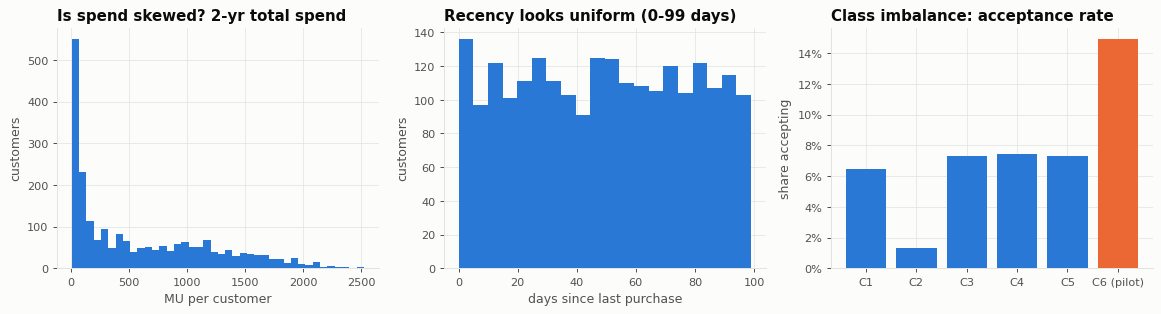

In [6]:
import matplotlib.pyplot as plt
from src.visualization import BLUE, ORANGE, INK2, pct_axis
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
tot = raw[MNT_COLS].sum(axis=1)
ax[0].hist(tot, bins=40, color=BLUE); ax[0].set_title('Is spend skewed? 2-yr total spend'); ax[0].set_xlabel('MU per customer'); ax[0].set_ylabel('customers')
ax[1].hist(raw.Recency, bins=20, color=BLUE); ax[1].set_title('Recency looks uniform (0-99 days)'); ax[1].set_xlabel('days since last purchase'); ax[1].set_ylabel('customers')
r = raw[CAMPAIGNS].mean(); ax[2].bar([CAMPAIGN_LABELS[c] for c in CAMPAIGNS], r, color=[BLUE]*5+[ORANGE]); pct_axis(ax[2])
ax[2].set_title('Class imbalance: acceptance rate'); ax[2].set_ylabel('share accepting')
plt.tight_layout()

**Reading:** spend is heavily right-skewed (median 396 vs max 2,525 MU) → log transforms for clustering; recency is
almost perfectly uniform across 0–99 days, which is unusual for real CRM data and suggests the file is a curated or
partly synthetic hiring-case dataset. Campaign acceptance is rare (1.3 %–15 %) → accuracy is meaningless; PR-AUC,
lift and profit are used later.

## Hillstrom: is the randomisation credible?

In [7]:
b = ctx['balance']; print('max |standardised mean difference| vs control:', round(b.smd.abs().max(), 4)); b.sort_values('smd', key=abs, ascending=False).head(6)

max |standardised mean difference| vs control: 0.0137


,arm,covariate,mean_arm,mean_control,smd
5,Mens E-Mail,zip_code_Rural,0.1522,0.1473,0.01366
6,Mens E-Mail,zip_code_Suburban,0.4459,0.4518,-0.01174
10,Mens E-Mail,channel_Web,0.4454,0.4399,0.01101
13,Womens E-Mail,mens,0.5489,0.5532,-0.008631
20,Womens E-Mail,channel_Phone,0.442,0.4378,0.008623
9,Mens E-Mail,channel_Phone,0.4337,0.4378,-0.008276


> **Finding:** Arms are balanced on every pre-treatment covariate (all |SMD| < 0.02).
>
> **Business implication:** Arm-vs-control differences in Hillstrom can be read as causal effects of the e-mails.
>
> **Recommended action:** Use Hillstrom for the incremental-response questions; use iFood for customer value, segments and response prediction.
>
> **Evidence:** Standardised mean differences on recency, history, buyer type, zip, channel, newbie.
>
> **Assumption:** The published assignment is the true random assignment.
>
> **Limitation:** The experiment is from 2008 and another retailer; findings are transferable lessons, not facts about iFood customers.

> **Finding:** iFood contains duplicate registrations (182 exact in the raw file, 19 conflicting-label groups), one placeholder income (666,666), three impossible birth years and non-standard marital labels. No transaction dates, campaign dates, campaign channel or campaign cost other than the constant 3 MU/contact and 11 MU/response.
>
> **Business implication:** Customer counts, response rates and profit would be inflated or biased without de-duplication; time-series and channel-attribution analyses are impossible.
>
> **Recommended action:** De-duplicate (documented), flag invalid values, and scope the project to what the matrix in DATA_AVAILABILITY.md supports.
>
> **Evidence:** Rule checks above; outputs/tables/data_quality_rule_checks.csv.
>
> **Assumption:** Rows identical on all 28 non-ID fields are the same customer.
>
> **Limitation:** Provenance of the case dataset is not documented; results describe this dataset, not a verified real population.